# Reproducible Visualization of Model Evaluation and Interpretability Analyses

This tutorial provides a **fully reproducible, modular visualization pipeline** for evaluating model performance, robustness, and interpretability in RNA–protein interaction studies. 

## Contents Overview

### 1. Modality-wise contributions to prediction
- Visualization:
  - Tile heatmaps with numeric annotations.
  - Metric-specific color scales (AUC, AUPRC, ACC, MCC).
- Output: PDF figures with size automatically scaled to matrix dimensions.

```{note}
Please download the pre-computed results from `Figshare` first, and place them in the expected directory.
```

##### Load required packages

To completely finish the following analysis, you need requires specific R packages listed below (`pkgs`), and you can verify and install using the code provided below.

Installing with conda solves most of the dependency package installation problems:
```
conda install conda-forge::r-tidyverse
```

The other packages can be installed just in R:

```
install.packages("readxl")
```

In [1]:
## Modality-wise contributions to prediction
# Load required libraries -------------------------------------------------
# tidyverse: data wrangling + ggplot2
# readxl   : read .xlsx files
library(tidyverse)
library(readxl)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Warning message in validate_heatmap_input(raw, metric):
“[MCC] Some CellLine columns are not numeric. Will attempt to coerce: H9, HEK293, HEK293T, HeLa, HepG2, K562”
Generating heatmap for: AUPRC

Warning message in validate_heatmap_input(raw, metric):
“[AUPRC] Some CellLine columns are not numeric. Will attempt to coerce: H9, HEK293, HEK293T, HeLa, HepG2, K562”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call.graphics(C_text, a

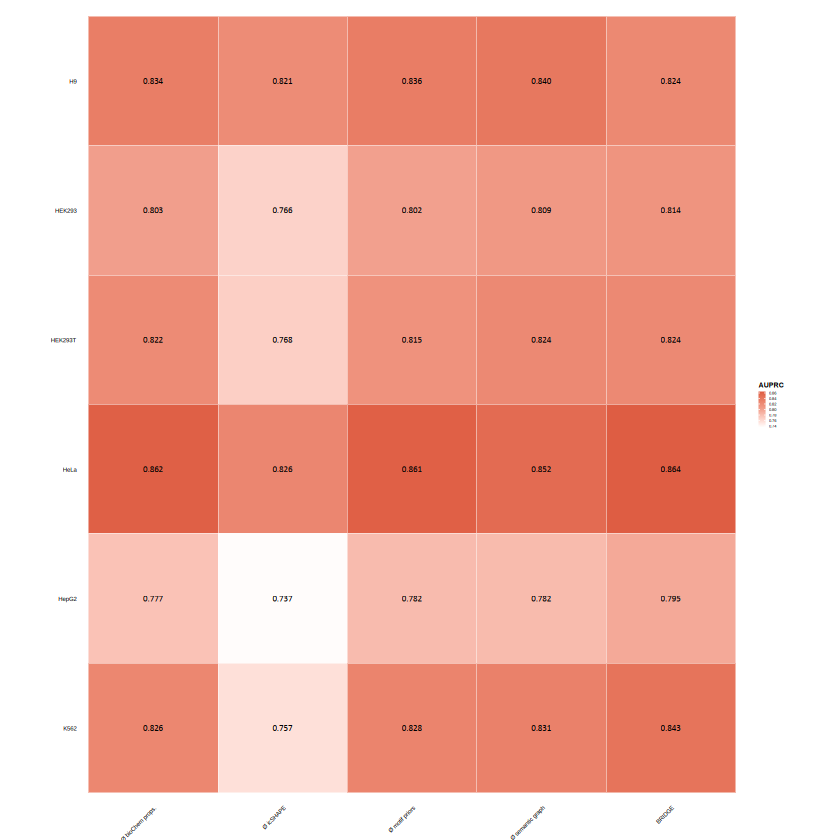

Generating heatmap for: MCC

Warning message in validate_heatmap_input(raw, metric):
“[MCC] Some CellLine columns are not numeric. Will attempt to coerce: H9, HEK293, HEK293T, HeLa, HepG2, K562”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label

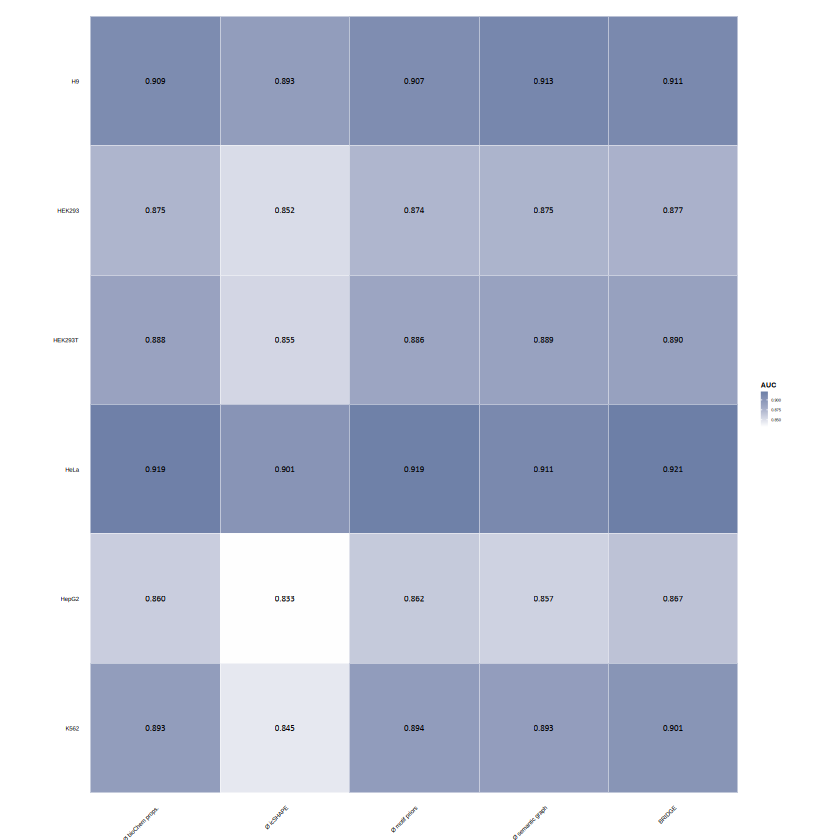

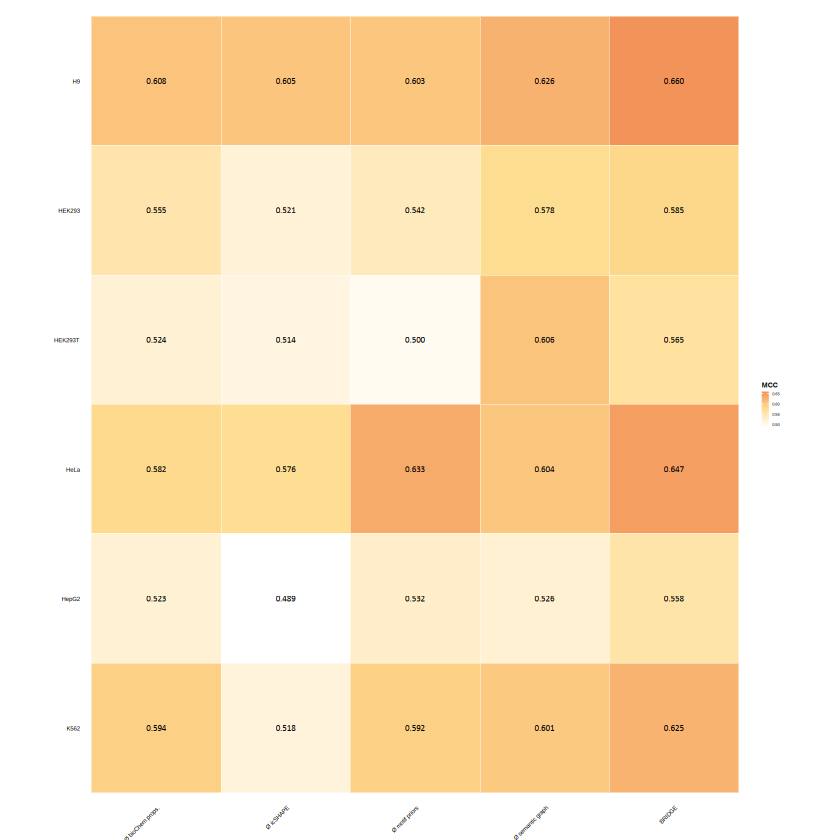

In [ ]:
# Helper: validate inputs -------------------------------------------------
validate_heatmap_input <- function(raw, metric) {
  # raw: data.frame read from Excel
  # metric: name of the metric (string), used for error messages only
  
  if (!("group" %in% colnames(raw))) {
    stop("Input Excel must contain a first column named 'group'.")
  }
   
  if (ncol(raw) < 2) {
    stop("Input Excel must have at least one CellLine column besides 'group'.")
  }
  
  cell_cols <- setdiff(colnames(raw), "group")
  if (length(cell_cols) == 0) {
    stop("No CellLine columns detected (columns other than 'group').")
  }
  
  # Check metric columns are numeric-like (readxl may read as numeric; but could be character if mixed)
  # We'll try to coerce later; here we only warn.
  non_numeric <- cell_cols[!map_lgl(raw[cell_cols], is.numeric)]
  if (length(non_numeric) > 0) {
    warning(
      sprintf(
        "[%s] Some CellLine columns are not numeric. Will attempt to coerce: %s",
        metric, paste(non_numeric, collapse = ", ")
      )
    )
  }
  
  invisible(TRUE)
}

# Plot + save a metric heatmap --------------------------------------------
plot_metric_heatmap <- function(
  xlsx,
  metric,
  pal, 
  midpoint,
  limits,
  file_out,
  cell = 0.8,
  sheet = NULL,
  na_label = "NA",
  na_fill = "grey95",
  digits = 3
) {
  #' Plot a metric heatmap from an Excel file and save to PDF.
  #'
  #' This function reads an Excel file in "wide" format (group x CellLine),
  #' converts it to long format, and draws a ggplot2 tile heatmap with numeric labels.
  #' The output PDF size is automatically scaled by the number of rows/columns.
  #'
  #' Parameters
  #' ----------
  #' xlsx : character
  #'   Path to the Excel file (.xlsx). Must include a column named 'group'.
  #'
  #' metric : character
  #'   Metric name used as the value column name after pivot_longer,
  #'   also used as legend title (e.g., "MCC", "AUC", "ACC", "AUPRC").
  #'
  #' pal : character vector (length = 3)
  #'   Color palette for low/mid/high in scale_fill_gradient2.
  #'   Example: c("#ffffff", "#fddc8e", "#f08852")
  #'
  #' midpoint : numeric
  #'   Midpoint value for scale_fill_gradient2.
  #'
  #' limits : numeric vector (length = 2)
  #'   Fill scale limits as c(min, max). Values outside will be squished.
  #'
  #' file_out : character
  #'   Output PDF filename/path. Use ".pdf".
  #'
  #' cell : numeric (default = 0.8)
  #'   Cell size factor (cm) used to compute PDF width/height:
  #'   width  = n_col * cell
  #'   height = n_row * cell
  #'
  #' sheet : character or numeric or NULL (default = NULL)
  #'   Optional. Excel sheet to read (passed to readxl::read_excel).
  #'   If NULL, read the first sheet.
  #'
  #' na_label : character (default = "NA")
  #'   Text label shown for missing values.
  #'
  #' na_fill : character (default = "grey95")
  #'   Tile fill color used for missing values.
  #'
  #' digits : integer (default = 3)
  #'   Number of digits for text labels (sprintf formatting).
  #'
  #' Returns
  #' -------
  #' A ggplot object (invisibly). The plot is also saved to file_out.
  #'
  #' Expected Input Format
  #' ---------------------
  #' A wide table with:
  #' - column 1: group
  #' - remaining columns: CellLine names
  #' Example:
  #' group | HepG2 | K562 | ...
  #'
  #' Common pitfalls
  #' ---------------
  #' - 'group' column name missing or misspelled (Group/group_id).
  #' - Non-numeric entries in metric columns (e.g., "0.62 " or "-").
  #' - Using wrong midpoint/limits leading to poor contrast.
  
  # 1) Read Excel ----------------------------------------------------------
  raw <- read_excel(path = xlsx, sheet = sheet)
  
  # Validate input structure
  validate_heatmap_input(raw, metric)
  
  # 2) Wide -> Long --------------------------------------------------------
  # Convert to long format:
  # group | CellLine | <metric>
  df <- raw %>%
    pivot_longer(
      cols = -group,
      names_to = "CellLine",
      values_to = metric
    ) %>%
    mutate(
      # preserve row/column ordering exactly as in the Excel file
      group    = factor(group, levels = raw$group),
      CellLine = factor(CellLine, levels = names(raw)[-1])
    )
  
  # Coerce to numeric if needed (safer for readxl mixed types)
  df[[metric]] <- suppressWarnings(as.numeric(df[[metric]]))
  
  # 3) Determine output size ----------------------------------------------
  n_row <- nlevels(df$CellLine)  # y-axis rows
  n_col <- nlevels(df$group)     # x-axis columns
  
  # 4) Label formatting ----------------------------------------------------
  # Label NA separately so sprintf doesn't print "NA" as " NA"
  fmt <- paste0("%.", digits, "f")
  df <- df %>%
    mutate(
      label = if_else(
        is.na(.data[[metric]]),
        na_label,
        sprintf(fmt, .data[[metric]])
      )
    )
  
  # 5) Plot ----------------------------------------------------------------
  p <- ggplot(df, aes(x = group, y = fct_rev(CellLine), fill = .data[[metric]])) +
    geom_tile(color = "white", linewidth = 0.1) +
    geom_text(
      aes(label = label),
      size = 1.75, fontface = "bold", family = "Calibri"
    ) +
    scale_fill_gradient2(
      low = pal[1], mid = pal[2], high = pal[3],
      midpoint = midpoint, limits = limits,
      na.value = na_fill,
      name = metric
    ) +
    scale_x_discrete(position = "bottom") +
    coord_fixed(1) +
    theme_minimal(base_size = 4) +
    theme(
      axis.title        = element_blank(),
      axis.ticks.length = unit(0, "pt"),
      axis.text.x       = element_text(
        angle = 45, hjust = 1, vjust = 1,
        colour = "black",
        margin = margin(t = -0.5)
      ),
      axis.text.y       = element_text(
        colour = "black",
        margin = margin(r = -0.5)
      ),
      panel.grid        = element_blank(),
      plot.margin       = margin(2, 2, 2, 2),
      legend.key.size   = unit(0.15, "cm"),
      legend.key.height = unit(0.15, "cm"),
      legend.key.width  = unit(0.15, "cm"),
      legend.title      = element_text(size = 4, face = "bold"),
      legend.text       = element_text(size = 2)
    )
  
  # 6) Save ----------------------------------------------------------------
  # Auto scale figure size by grid dimension
  ggsave(
    filename = file_out,
    plot     = p,
    width    = n_col * cell,
    height   = n_row * cell,
    units    = "cm",
    device   = cairo_pdf
  )
  
  invisible(p)
}

# Metric configurations ----------------------------------------------------

cfg <- list(
  AUPRC = list(
    xlsx     = "../ablation&interpretability/heatmap_AUPRC.xlsx",
    pal      = c("#ffffff", "#f2a290", "#de5c42"),
    midpoint = 0.80,
    limits   = c(0.737, 0.865),
    out      = "heatmap_AUPRC.pdf"
  ),
  AUC = list(
    xlsx     = "../ablation&interpretability/heatmap_AUC.xlsx",
    pal      = c("#ffffff", "#a4acc7", "#6377A1"),
    midpoint = 0.88,
    limits   = c(0.832, 0.921),
    out      = "heatmap_AUC.pdf"
  ),
  MCC = list(
    xlsx     = "../ablation&interpretability/heatmap_MCC.xlsx",
    pal      = c("#ffffff", "#fddc8e", "#f08852"),
    midpoint = 0.58,
    limits   = c(0.489, 0.660),
    out      = "heatmap_MCC.pdf"
  )
)

# Global plot sizing (cm per tile)
cell_size_cm <- 0.8

# Run: MCC heatmap ---------------------------------------------------------
plot_metric_heatmap(
  xlsx     = cfg$MCC$xlsx,
  metric   = "MCC",
  pal      = cfg$MCC$pal,
  midpoint = cfg$MCC$midpoint,
  limits   = cfg$MCC$limits,
  file_out = cfg$MCC$out,
  cell     = cell_size_cm
)

for (m in names(cfg)) {
  message("Generating heatmap for: ", m)
  p <- plot_metric_heatmap(
    xlsx     = cfg[[m]]$xlsx,
    metric   = m,
    pal      = cfg[[m]]$pal,
    midpoint = cfg[[m]]$midpoint,
    limits   = cfg[[m]]$limits,
    file_out = cfg[[m]]$out,
    cell     = cell_size_cm
  )
  print(p)
}
